Using device: cuda
SimpleUNet has 600,449 parameters
epoch  1 | train loss 0.0119 | val loss 0.0053
epoch  2 | train loss 0.0048 | val loss 0.0045
epoch  3 | train loss 0.0043 | val loss 0.0040
epoch  4 | train loss 0.0040 | val loss 0.0038
epoch  5 | train loss 0.0038 | val loss 0.0039
epoch  6 | train loss 0.0037 | val loss 0.0037
epoch  7 | train loss 0.0036 | val loss 0.0035
epoch  8 | train loss 0.0035 | val loss 0.0034
Saved denoising_examples.png


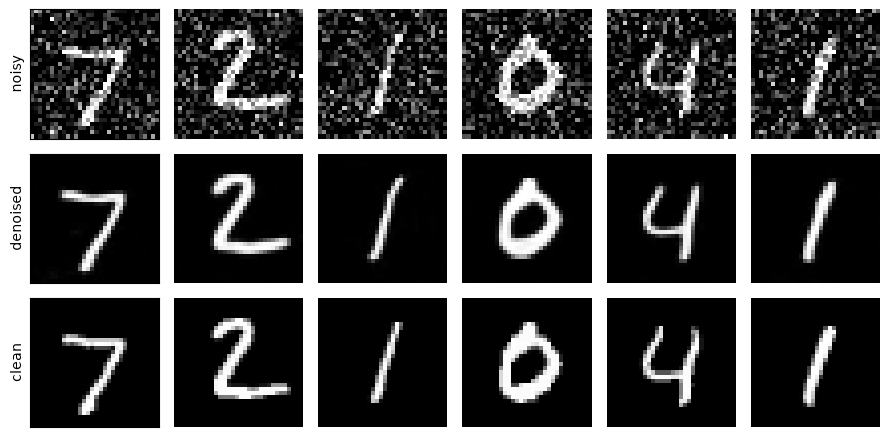

In [1]:
"""
Small UNet for MNIST denoising.

Implements the plan from our walkthrough:
  1. Data:   MNIST padded 28x28 -> 32x32, Gaussian noise added on the fly.
  2. Model:  3-level UNet, channel plan  32x32:32ch -> 16x16:64ch -> 8x8:128ch (bottleneck).
  3. Blocks: two 3x3 convs (GroupNorm + ReLU) per level.
  4. Skips:  encoder features concatenated into the matching decoder level.
  5. Loss:   MSE between predicted and clean image.
  6/7. Train + visualize noisy / denoised / clean triplets.

Also includes SimpleUNetNoSkip, an ablation that zeroes the skip connections
so you can directly compare denoising quality with and without them.

Usage:
    python mnist_unet_denoising.py
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.backends.cudnn.enabled = False


# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------

class DoubleConv(nn.Module):
    """Two 3x3 convs, each followed by GroupNorm + ReLU."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    """Halve spatial resolution with a stride-2 conv, then a DoubleConv block."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.downsample = nn.Conv2d(in_ch, in_ch, kernel_size=4, stride=2, padding=1)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        x = self.downsample(x)
        return self.conv(x)


class Up(nn.Module):
    """
    Double spatial resolution (nearest upsample + conv, to avoid the
    checkerboard artifacts a transposed conv can introduce), concatenate the
    skip connection from the matching encoder level, then a DoubleConv block.
    """

    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.up_conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = self.up_conv(x)
        x = torch.cat([x, skip], dim=1)  # channel-wise concat
        return self.conv(x)


class SimpleUNet(nn.Module):
    """
    Small UNet for MNIST denoising.

    Resolution / channel plan:
        32x32 ->  32ch  (stem)
        16x16 ->  64ch
         8x8  -> 128ch  (bottleneck)
    """

    def __init__(self, in_channels=1, base_ch=32):
        super().__init__()
        self.stem = DoubleConv(in_channels, base_ch)             # 32x32, 32ch
        self.down1 = Down(base_ch, base_ch * 2)                  # 16x16, 64ch
        self.down2 = Down(base_ch * 2, base_ch * 4)              # 8x8, 128ch (bottleneck)

        self.up1 = Up(base_ch * 4, base_ch * 2, base_ch * 2)     # -> 16x16, 64ch
        self.up2 = Up(base_ch * 2, base_ch, base_ch)             # -> 32x32, 32ch

        self.out_conv = nn.Conv2d(base_ch, in_channels, kernel_size=1)

    def forward(self, x):
        s1 = self.stem(x)      # 32x32, 32ch   (skip)
        s2 = self.down1(s1)    # 16x16, 64ch   (skip)
        b = self.down2(s2)     # 8x8,  128ch   (bottleneck)

        u1 = self.up1(b, s2)   # 16x16, 64ch
        u2 = self.up2(u1, s1)  # 32x32, 32ch

        return self.out_conv(u2)


class SimpleUNetNoSkip(SimpleUNet):
    """
    Same architecture, but the skip connections are zeroed out before the
    decoder uses them. Train this alongside SimpleUNet with identical
    hyperparameters to see directly what the skip connections buy you.
    """

    def forward(self, x):
        s1 = self.stem(x)
        s2 = self.down1(s1)
        b = self.down2(s2)

        u1 = self.up1(b, torch.zeros_like(s2))
        u2 = self.up2(u1, torch.zeros_like(s1))

        return self.out_conv(u2)


# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------

def get_dataloaders(batch_size=128, data_dir="./data"):
    transform = transforms.Compose([
        transforms.Pad(2),      # 28x28 -> 32x32, so 3 rounds of /2 land on integers
        transforms.ToTensor(),  # pixel values in [0, 1]
    ])
    train_ds = torchvision.datasets.MNIST(data_dir, train=True, download=True, transform=transform)
    val_ds = torchvision.datasets.MNIST(data_dir, train=False, download=True, transform=transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader


def add_noise(x, sigma=0.3):
    """Fixed-noise-level corruption: x_noisy = x + sigma * epsilon."""
    return x + sigma * torch.randn_like(x)


# ---------------------------------------------------------------------------
# Training / evaluation
# ---------------------------------------------------------------------------

def train(model, train_loader, val_loader, device, epochs=8, lr=2e-4, sigma=0.3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            x_noisy = add_noise(x, sigma)

            pred = model(x_noisy)
            loss = F.mse_loss(pred, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss = evaluate(model, val_loader, device, sigma)
        print(f"epoch {epoch:2d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

    return model


@torch.no_grad()
def evaluate(model, loader, device, sigma=0.3):
    model.eval()
    total_loss = 0.0
    for x, _ in loader:
        x = x.to(device)
        x_noisy = add_noise(x, sigma)
        pred = model(x_noisy)
        loss = F.mse_loss(pred, x)
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------

@torch.no_grad()
def show_denoising_examples(model, val_loader, device, sigma=0.3, n=6, out_path="denoising_examples.png"):
    model.eval()
    x, _ = next(iter(val_loader))
    x = x[:n].to(device)
    x_noisy = add_noise(x, sigma)
    pred = model(x_noisy)

    x, x_noisy, pred = x.cpu(), x_noisy.cpu(), pred.cpu()

    fig, axes = plt.subplots(3, n, figsize=(n * 1.5, 4.5))
    row_labels = ["noisy", "denoised", "clean"]
    rows = [x_noisy, pred.clamp(0, 1), x]

    for row, (label, imgs) in enumerate(zip(row_labels, rows)):
        for col in range(n):
            axes[row, col].imshow(imgs[col, 0], cmap="gray", vmin=0, vmax=1)
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(label, fontsize=10)
        axes[row, 0].axis("on")
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    print(f"Saved {out_path}")


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    # device = torch.device("cpu")

    train_loader, val_loader = get_dataloaders(batch_size=128)

    model = SimpleUNetNoSkip(in_channels=1, base_ch=32)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"SimpleUNet has {n_params:,} parameters")

    model = train(model, train_loader, val_loader, device, epochs=8, sigma=0.3)
    show_denoising_examples(model, val_loader, device, sigma=0.3)

    # Skip-connection ablation: uncomment to train the no-skip version too
    # and compare denoising_examples.png against no_skip_examples.png.
    #
    # noskip_model = SimpleUNetNoSkip(in_channels=1, base_ch=32)
    # noskip_model = train(noskip_model, train_loader, val_loader, device, epochs=8, sigma=0.3)
    # show_denoising_examples(noskip_model, val_loader, device, sigma=0.3,
    #                          out_path="no_skip_examples.png")

In [3]:
   print(torch.__version__, torch.version.cuda, torch.backends.cudnn.version())

2.13.0+cu130 13.0 92000


In [7]:
model.stem

DoubleConv(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (5): ReLU(inplace=True)
  )
)